**Dataset:** `data/titanic.csv` (891 passengers). The placement columns of the original notebook are mapped to Titanic columns as described below.

Mapping: multi-class target `CGPA_Tier` (Low/Mid/High) → `Pclass` (1/2/3); `Pclass` is removed from the features.

# Multinomial Logistic Regression — Pclass

## Objective
Develop a Logistic Regression classification model to predict **`Pclass`** and evaluate it using standard classification metrics.

### Data assumption
The data is already preprocessed:
- `X_train` = 80% preprocessed features
- `X_test` = 20% preprocessed features
- `y_train` = target for training
- `y_test` = target for testing

**No additional imputation, encoding, or scaling is performed here.**

### Required outputs
- `evaluate_classifier()` function
- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix
- Classification report
- Coefficient bar chart


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score
)


## 2. Load Already-Preprocessed Data

In [2]:
# Change these paths to your actual files
X_TRAIN_PATH = "/Users/divyasaisomana/placement prediction system/data/titanic_X_train_processed.csv"
X_TEST_PATH  = "/Users/divyasaisomana/placement prediction system/data/titanic_X_test_processed.csv"
#Y_TRAIN_PATH = "/Users/divyasaisomana/placement prediction system/data/y_train_Pclass.csv"
#Y_TEST_PATH  = "/Users/divyasaisomana/placement prediction system/data/y_test_Pclass.csv"

X_train = pd.read_csv(X_TRAIN_PATH)
X_test = pd.read_csv(X_TEST_PATH)

y_train = X_train['Pclass']
y_test = X_test['Pclass']
X_train1=X_train.drop(columns=['Pclass'])
X_test1=X_test.drop(columns=['Pclass'])

if isinstance(y_train, pd.DataFrame) and y_train.shape[1] == 1:
    y_train = y_train.iloc[:, 0]
if isinstance(y_test, pd.DataFrame) and y_test.shape[1] == 1:
    y_test = y_test.iloc[:, 0]

print("X_train1:", X_train.shape)
print("X_test :", X_test1.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTarget distribution:")
print(y_train.value_counts().sort_index())


X_train1: (712, 8)
X_test : (179, 7)
y_train: (712,)
y_test : (179,)

Target distribution:
Pclass
1    171
2    150
3    391
Name: count, dtype: int64


## 3. Verify Preprocessed Data

In [3]:
print("Missing values in X_train:", X_train1.isna().sum().sum())
print("Missing values in X_test :", X_test1.isna().sum().sum())

print("\nFeature columns:")
print(list(X_train1.columns))

print("\nTarget classes:")
print(sorted(pd.Series(y_train).unique()))


Missing values in X_train: 0
Missing values in X_test : 0

Feature columns:
['Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']

Target classes:
[np.int64(1), np.int64(2), np.int64(3)]


In [4]:
print("Categorical columns in X_train1:")
print(X_train1.select_dtypes(include="object").columns)

Categorical columns in X_train1:
Index([], dtype='str')


In [5]:
X_train1.columns

Index(['Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q',
       'Embarked_S'],
      dtype='str')

## 4. Train Multinomial Logistic Regression

`Pclass` contains multiple classes, so multinomial Logistic Regression is used.


In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=3000,
    random_state=42
)

model.fit(X_train1, y_train)

print("Model trained successfully.")
print("Classes:", model.classes_)

Model trained successfully.
Classes: [1 2 3]


## 5. Define `evaluate_classifier()`

In [7]:
def evaluate_classifier(model, X, y, dataset_name="Dataset"):
    y_pred = model.predict(X)

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(
        y, y_pred, average="weighted", zero_division=0
    )
    recall = recall_score(
        y, y_pred, average="weighted", zero_division=0
    )
    f1 = f1_score(
        y, y_pred, average="weighted", zero_division=0
    )

    print(f"===== {dataset_name} =====")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y, y_pred, zero_division=0))

    print("Confusion Matrix:")
    print(confusion_matrix(y, y_pred))

    return {
        "Dataset": dataset_name,
        "Accuracy": accuracy,
        "Precision_weighted": precision,
        "Recall_weighted": recall,
        "F1_weighted": f1
    }


## 6. Evaluate Training and Test Performance

In [8]:
train_results = evaluate_classifier(
    model, X_train1, y_train, "Training"
)

test_results = evaluate_classifier(
    model, X_test1, y_test, "Test"
)

evaluation_df = pd.DataFrame([
    train_results,
    test_results
])

display(evaluation_df)


===== Training =====
Accuracy : 0.7963
Precision: 0.7826
Recall   : 0.7963
F1-score : 0.7645

Classification Report:
              precision    recall  f1-score   support

           1       0.91      0.87      0.89       171
           2       0.66      0.25      0.37       150
           3       0.77      0.97      0.86       391

    accuracy                           0.80       712
   macro avg       0.78      0.70      0.71       712
weighted avg       0.78      0.80      0.76       712

Confusion Matrix:
[[149  15   7]
 [  8  38 104]
 [  6   5 380]]
===== Test =====
Accuracy : 0.8156
Precision: 0.7927
Recall   : 0.8156
F1-score : 0.7806

Classification Report:
              precision    recall  f1-score   support

           1       0.95      0.89      0.92        45
           2       0.58      0.21      0.30        34
           3       0.79      0.99      0.88       100

    accuracy                           0.82       179
   macro avg       0.78      0.69      0.70       179

,Dataset,Accuracy,Precision_weighted,Recall_weighted,F1_weighted
0,Training,0.796348,0.782578,0.796348,0.764456
1,Test,0.815642,0.792684,0.815642,0.780599


## 7. Test Confusion Matrix

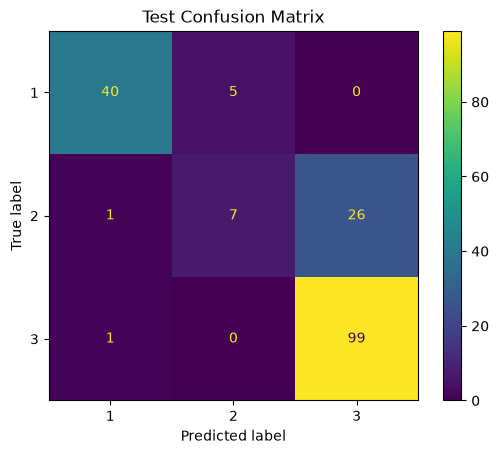

In [9]:
y_test_pred = model.predict(X_test1)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    values_format="d"
)

plt.title("Test Confusion Matrix")
plt.show()


## 8. Coefficients

In [10]:
# Binary: one coefficient per feature.
# Multinomial: one coefficient row per class.

if model.coef_.shape[0] == 1:
    coefficient_df = pd.DataFrame({
        "Feature": X_train1.columns,
        "Coefficient": model.coef_[0]
    })
    display(coefficient_df)

else:
    coefficient_df = pd.DataFrame(
        model.coef_,
        index=[f"Class={c}" for c in model.classes_],
        columns=X_train1.columns
    )
    display(coefficient_df)


,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
Class=1,0.481818,-1.167878,-0.510903,3.842292,-0.146544,-0.924360,-0.667951
Class=2,-0.125745,0.241514,0.071247,0.179677,-0.223565,-0.254216,0.783768
Class=3,-0.356073,0.926364,0.439657,-4.021970,0.370109,1.178576,-0.115817


## 9. Coefficient Bar Chart

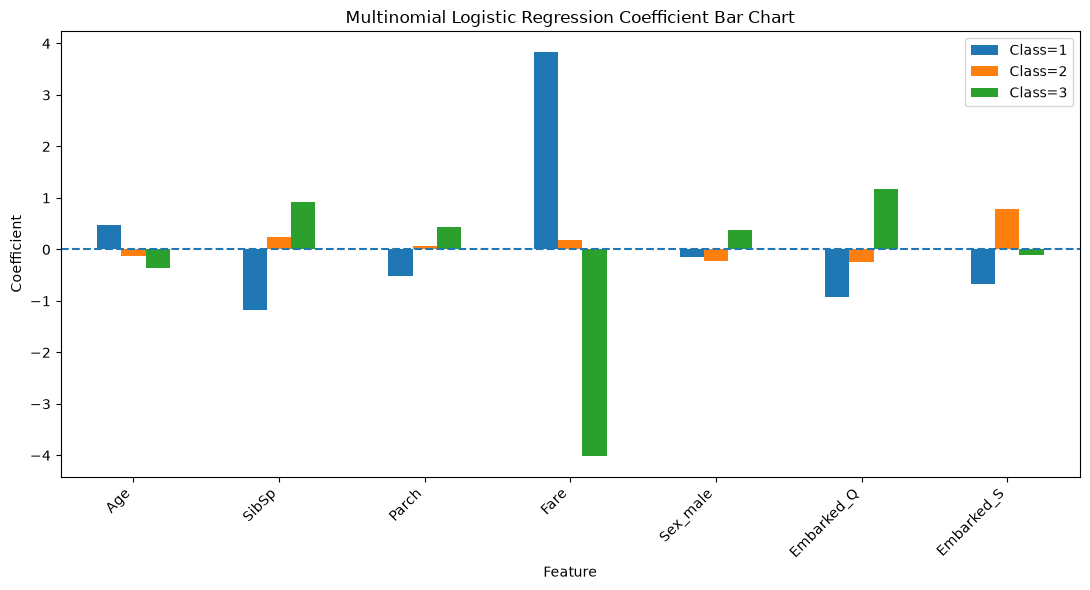

In [11]:
if model.coef_.shape[0] == 1:

    plot_df = pd.DataFrame({
        "Feature": X_train1.columns,
        "Coefficient": model.coef_[0]
    }).sort_values("Coefficient")

    plt.figure(figsize=(9, 6))
    plt.barh(plot_df["Feature"], plot_df["Coefficient"])
    plt.axvline(0, linestyle="--")
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.title("Logistic Regression Coefficient Bar Chart")
    plt.tight_layout()
    plt.show()

else:
    coefficient_plot_df = coefficient_df.T

    ax = coefficient_plot_df.plot(
        kind="bar",
        figsize=(11, 6)
    )

    ax.axhline(0, linestyle="--")
    ax.set_xlabel("Feature")
    ax.set_ylabel("Coefficient")
    ax.set_title("Multinomial Logistic Regression Coefficient Bar Chart")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


# Interpretation and Conclusion

### Target
This notebook predicts **`Pclass`**.

### Metrics
- Accuracy: overall percentage of correct predictions.
- Precision: correctness of positive predictions.
- Recall: ability to identify actual positive cases.
- F1-score: balance between precision and recall.
- ROC-AUC: used for the binary model to measure discrimination across thresholds.

### Coefficients
A positive coefficient increases the model's tendency toward the corresponding class; a negative coefficient decreases it, subject to the preprocessing and class formulation.

### Final evaluation
The **test-set metrics** are the final performance results because `X_test` and `y_test` are kept separate from model fitting.
